##### 05 - Galaxy Redshift Regression

Train regression models to predict galaxy redshift `z` from photometric
features.

Phase 3 EDA suggested that raw magnitudes have a stronger visible and linear
relationship with redshift than color indices, although both feature groups
will be included in the models.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
GALAXY_PATH = PROCESSED_DIR / "sdss_galaxy_redshift.csv"

df_galaxy = pd.read_csv(GALAXY_PATH)

df_galaxy.shape

(49402, 18)

In [4]:
features = [
    "dered_u",
    "dered_g",
    "dered_r",
    "dered_i",
    "dered_z",
    "u_g",
    "g_r",
    "r_i",
    "i_z",
]

target = "z"

X = df_galaxy[features].copy()
y = df_galaxy[target].copy()

In [5]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values:")
print(df_galaxy[features + [target]].isnull().sum())

y.describe()

Feature shape: (49402, 9)
Target shape: (49402,)

Missing values:
dered_u    0
dered_g    0
dered_r    0
dered_i    0
dered_z    0
u_g        0
g_r        0
r_i        0
i_z        0
z          0
dtype: int64


count    49402.000000
mean         0.275863
std          0.256418
min          0.000053
25%          0.084763
50%          0.142197
75%          0.455774
max          0.999834
Name: z, dtype: float64

The regression dataset contains only galaxy objects with `0 < z < 1`, and the
selected modeling columns contain no missing values.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

X_train.shape, X_test.shape

((39521, 9), (9881, 9))

In [7]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
    ),
}

In [8]:
results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = y_pred

    results.append({
        "model": name,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(["mae", "rmse"])
    .reset_index(drop=True)
)

results_df

,model,mae,rmse,r2
0,Random Forest,0.032216,0.066071,0.933607
1,Gradient Boosting,0.036250,0.068174,0.929313
2,Ridge,0.066969,0.102648,0.839749
3,Dummy,0.217133,0.256422,-0.000023


In [9]:
best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best model by MAE:", best_model_name)

Best model by MAE: Random Forest


Random Forest is the strongest model, achieving the lowest MAE (0.032) and
the highest R² (0.934), closely followed by Gradient Boosting.

Both tree-based models outperform Ridge, indicating that non-linear
relationships and feature interactions improve redshift prediction. However,
Ridge still explains approximately 84% of the target variance, suggesting that
the selected photometric features also contain a substantial linear signal.

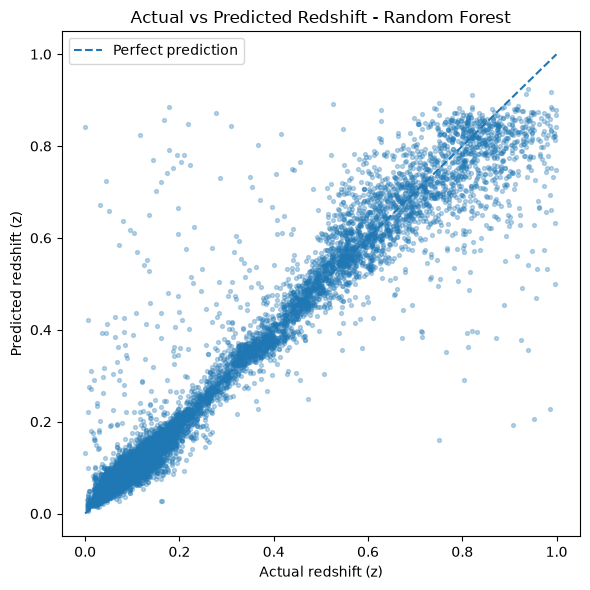

In [11]:
plot_min = min(y_test.min(), best_pred.min())
plot_max = max(y_test.max(), best_pred.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.3, s=8)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    label="Perfect prediction",
)

plt.xlabel("Actual redshift (z)")
plt.ylabel("Predicted redshift (z)")
plt.title(f"Actual vs Predicted Redshift - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

Random Forest predictions follow the perfect-prediction line closely across
much of the low-to-middle redshift range, which is consistent with its strong
overall R² score.

However, predictions become more dispersed at higher redshift. Many objects
with actual `z` above approximately 0.7 fall below the diagonal line,
indicating that the model tends to underpredict high-redshift galaxies.

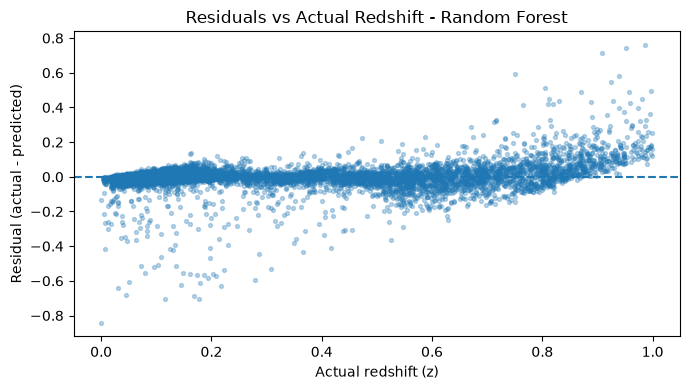

In [13]:
residuals = y_test.to_numpy() - best_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_test, residuals, alpha=0.3, s=8)
plt.axhline(0, linestyle="--")

plt.xlabel("Actual redshift (z)")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residuals vs Actual Redshift - {best_model_name}")
plt.tight_layout()
plt.show()

Residuals remain relatively concentrated around zero at low redshift, but
their spread increases as actual redshift rises. This indicates that prediction
uncertainty is not constant across the target range.

Residuals also become predominantly positive at high redshift. Since residual
is defined as `actual - predicted`, this confirms that the model increasingly
underpredicts galaxies at the upper end of the redshift range.

In [14]:
evaluation_df = pd.DataFrame({
    "actual_z": y_test.to_numpy(),
    "predicted_z": best_pred,
})

evaluation_df["residual"] = (
    evaluation_df["actual_z"] - evaluation_df["predicted_z"]
)

evaluation_df["absolute_error"] = np.abs(
    evaluation_df["residual"]
)

In [15]:
bin_edges = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

evaluation_df["redshift_bin"] = pd.cut(
    evaluation_df["actual_z"],
    bins=bin_edges,
    include_lowest=True,
)

error_by_bin = (
    evaluation_df
    .groupby("redshift_bin", observed=True)
    .agg(
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        sample_count=("absolute_error", "size"),
    )
    .reset_index()
)

error_by_bin

,redshift_bin,mean_absolute_error,median_absolute_error,sample_count
0,"(-0.001, 0.1]",0.018083,0.010859,3238
1,"(0.1, 0.2]",0.021609,0.012039,2721
2,"(0.2, 0.4]",0.031297,0.015111,1153
3,"(0.4, 0.6]",0.040553,0.026226,1209
4,"(0.6, 0.8]",0.055283,0.042525,985
5,"(0.8, 1.0]",0.106794,0.078904,575


Prediction error increases consistently across the redshift bins. Mean absolute
error rises from 0.018 in the lowest-redshift bin to 0.107 in the `0.8–1.0`
bin, making the average error at the upper end nearly six times larger.

Median absolute error follows the same upward pattern, showing that the weaker
high-redshift performance is not caused only by a small number of extreme
outliers. At the same time, the number of test samples decreases substantially
toward higher redshift.

These results confirm that the model performs unevenly across the target
range. The smaller number of high-redshift examples may contribute to this
pattern, although it should not be treated as the only possible cause.

#### Regression Summary

Random Forest is the strongest regression model, achieving an MAE of 0.032,
an RMSE of 0.066, and an R² of 0.934. Gradient Boosting performs closely
behind it, while both tree-based models outperform Ridge and the mean-based
Dummy baseline.

Despite its strong overall metrics, Random Forest performance varies across
the redshift range. Predictions are most accurate for low-to-middle redshift
galaxies, while error and residual spread increase toward higher redshift.
The model also shows a tendency to underpredict galaxies near the upper end
of the target range.

Error-by-bin analysis reinforces this limitation: MAE increases from 0.018
in the lowest bin to 0.107 in the `0.8–1.0` bin. Therefore, the overall score
should not be interpreted as equally strong performance for every galaxy.
Random Forest remains the selected model, with high-redshift prediction
identified as its main weakness.

#### Export Final Regression Model

After model selection and test-set evaluation, the selected Random Forest is
retrained on the full regression dataset for use in the Streamlit application.
The reported evaluation metrics remain based on the original held-out test set.

In [16]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

final_regressor.fit(X, y)

regression_artifact = {
    "model": final_regressor,
    "model_name": "Random Forest",
    "features": features,
    "target": target,
}

regressor_path = MODELS_DIR / "redshift_regressor.joblib"

joblib.dump(
    regression_artifact,
    regressor_path,
    compress=3,
)

print("Saved:", regressor_path.relative_to(PROJECT_ROOT))
print(f"File size: {regressor_path.stat().st_size / 1024**2:.2f} MB")

Saved: models\redshift_regressor.joblib
File size: 237.67 MB


In [17]:
loaded_regressor = joblib.load(regressor_path)

sample_input = X.iloc[[0]][loaded_regressor["features"]]
sample_prediction = loaded_regressor["model"].predict(sample_input)[0]

print("Loaded model:", type(loaded_regressor["model"]).__name__)
print("Features:", loaded_regressor["features"])
print(f"Sample predicted z: {sample_prediction:.4f}")

Loaded model: RandomForestRegressor
Features: ['dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z', 'u_g', 'g_r', 'r_i', 'i_z']
Sample predicted z: 0.5389


#### Export Deployment Regression Model

Random Forest achieved the strongest test-set performance, but its serialized
artifact is relatively large. Gradient Boosting is therefore also exported as
a deployment candidate because it provides similar predictive performance
with a potentially smaller storage and memory footprint.

In [18]:
deployment_regressor = GradientBoostingRegressor(
    random_state=42,
)

deployment_regressor.fit(X, y)

deployment_artifact = {
    "model": deployment_regressor,
    "model_name": "Gradient Boosting",
    "features": features,
    "target": target,
    "evaluation": {
        "mae": 0.036250,
        "rmse": 0.068174,
        "r2": 0.929313,
    },
    "purpose": "Streamlit deployment",
}

deployment_regressor_path = (
    MODELS_DIR / "redshift_regressor_deploy.joblib"
)

joblib.dump(
    deployment_artifact,
    deployment_regressor_path,
    compress=3,
)

print(
    "Saved:",
    deployment_regressor_path.relative_to(PROJECT_ROOT),
)

print(
    f"File size: "
    f"{deployment_regressor_path.stat().st_size / 1024**2:.2f} MB"
)

Saved: models\redshift_regressor_deploy.joblib
File size: 0.05 MB


In [19]:
loaded_deployment_regressor = joblib.load(
    deployment_regressor_path
)

sample_input = X.iloc[[0]][
    loaded_deployment_regressor["features"]
]

sample_prediction = (
    loaded_deployment_regressor["model"]
    .predict(sample_input)[0]
)

print(
    "Loaded model:",
    type(loaded_deployment_regressor["model"]).__name__,
)

print(
    "Model name:",
    loaded_deployment_regressor["model_name"],
)

print(
    f"Sample predicted z: {sample_prediction:.4f}"
)

Loaded model: GradientBoostingRegressor
Model name: Gradient Boosting
Sample predicted z: 0.5098
